In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Added imports based on what we discussed in the previous video from 17 Mar 26 regarding CNNs.
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.optim as optim
import time
import pandas as pd

In [2]:
# torch.manual_seed(42)
# np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
input_size = 784
# hidden_size = 0
num_classes = 10
num_epochs = 20
batch_size = 100
learning_rate = 0.01

In [4]:
# MNIST dataset 
train_dataset = torchvision.datasets.MNIST(root='../../data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='../../data', 
                                          train=False, 
                                          transform=transforms.ToTensor())

# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 449kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.69MB/s]


In [5]:
class ClassificationNet1(nn.Module):
    # 4-layer network: 20 -> 50 -> 20 -> 10
    def __init__(self, input_size, num_classes):
        super(ClassificationNet1, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.fc2 = nn.Linear(20, 50)
        self.fc3 = nn.Linear(50, 20)
        self.fc4 = nn.Linear(20, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.relu(self.fc2(out))
        out = self.relu(self.fc3(out))
        out = self.fc4(out)
        return out
      
      
class ClassificationNet2(nn.Module):
    # 6-layer network: 10 -> 20 -> 30 -> 20 -> 10 -> 10
    def __init__(self, input_size, num_classes):
        super(ClassificationNet2, self).__init__()
        self.fc1 = nn.Linear(input_size, 10)
        self.fc2 = nn.Linear(10, 20)
        self.fc3 = nn.Linear(20, 30)
        self.fc4 = nn.Linear(30, 20)
        self.fc5 = nn.Linear(20, 10)
        self.fc6 = nn.Linear(10, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.relu(self.fc2(out))
        out = self.relu(self.fc3(out))
        out = self.relu(self.fc4(out))
        out = self.relu(self.fc5(out))
        out = self.fc6(out)
        return out

class ClassificationNet3(nn.Module):
    # 6-layer network: 10 -> 40 -> 70 -> 40 -> 10 -> 10
    def __init__(self, input_size, num_classes):
        super(ClassificationNet3, self).__init__()
        self.fc1 = nn.Linear(input_size, 10)
        self.fc2 = nn.Linear(10, 40)
        self.fc3 = nn.Linear(40, 70)
        self.fc4 = nn.Linear(70, 40)
        self.fc5 = nn.Linear(40, 10)
        self.fc6 = nn.Linear(10, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.relu(self.fc2(out))
        out = self.relu(self.fc3(out))
        out = self.relu(self.fc4(out))
        out = self.relu(self.fc5(out))
        out = self.fc6(out)
        return out

In [6]:
def train_classification_model(model, train_loader, val_loader, num_epochs):
    model = model.to(device)
    # Loss and optimizer
    # CrossEntropyLoss includes softmax internally, so no need to apply it explicitly in the output layer
    criterion = nn.CrossEntropyLoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 
    
    train_losses = []
    val_losses = []

    start_time = time.time()
    val_accu = []
    
    # Train the model
    total_step = len(train_loader)
    
    # Training loop: forward pass, loss computation, backward pass, and optimization
    for epoch in range(num_epochs):
        model.train()  
        running_train_loss = 0.0
        
        for i, (images, labels) in enumerate(train_loader):  
            # Move tensors to the configured device
            images = images.reshape(-1, 28*28).to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Back propagation and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            
            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                    .format(epoch+1, num_epochs, i+1, total_step, loss.item()))
                
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
            
        # Evaluate model performance on validation data
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0
                
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.reshape(-1, 28*28).to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        epoch_acc = 100 * correct / total
        val_accu.append(epoch_acc)

        print(
            f"Epoch [{epoch+1:02d}/{num_epochs}] | "
            f"Val Acc: {epoch_acc:.2f}%")

    train_time = time.time() - start_time
    return model, train_losses, val_losses, val_accu, train_time

In [7]:
results_classification = {}

models_classification = {
    "Network 1": ClassificationNet1(input_size, num_classes),
    "Network 2": ClassificationNet2(input_size, num_classes),
    "Network 3": ClassificationNet3(input_size, num_classes),
}

for name, model in models_classification.items():
    print(f"\nTraining {name}...")
    
    # Using test set as validation for simplicity (no separate validation set provided)
    trained_model, train_losses, val_losses, val_accu, train_time = train_classification_model(
        model, train_loader, test_loader, num_epochs
    )

    results_classification[name] = {
        "model": trained_model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accu": val_accu,
        "train_time_sec": train_time,
        "final_val_acc": val_accu[-1]
    }


Training Network 1...
Epoch [1/20], Step [100/600], Loss: 0.4730
Epoch [1/20], Step [200/600], Loss: 0.3527
Epoch [1/20], Step [300/600], Loss: 0.2865
Epoch [1/20], Step [400/600], Loss: 0.3637
Epoch [1/20], Step [500/600], Loss: 0.2159
Epoch [1/20], Step [600/600], Loss: 0.2115
Epoch [01/20] | Val Acc: 92.70%
Epoch [2/20], Step [100/600], Loss: 0.0734
Epoch [2/20], Step [200/600], Loss: 0.2174
Epoch [2/20], Step [300/600], Loss: 0.3585
Epoch [2/20], Step [400/600], Loss: 0.1829
Epoch [2/20], Step [500/600], Loss: 0.2451
Epoch [2/20], Step [600/600], Loss: 0.0849
Epoch [02/20] | Val Acc: 93.36%
Epoch [3/20], Step [100/600], Loss: 0.1679
Epoch [3/20], Step [200/600], Loss: 0.1434
Epoch [3/20], Step [300/600], Loss: 0.2214
Epoch [3/20], Step [400/600], Loss: 0.0787
Epoch [3/20], Step [500/600], Loss: 0.1190
Epoch [3/20], Step [600/600], Loss: 0.2770
Epoch [03/20] | Val Acc: 93.98%
Epoch [4/20], Step [100/600], Loss: 0.1313
Epoch [4/20], Step [200/600], Loss: 0.1762
Epoch [4/20], Step [3

In [8]:
summary_rows = []
for name, info in results_classification.items():
    summary_rows.append({
        "Model": name,
        "Final Train Loss": info["train_losses"][-1],
        "Final Validation Loss": info["val_losses"][-1],
        "Final Validation Accuracy (%)": info["final_val_acc"],
        "Training Time (sec)": info["train_time_sec"]
    })
    
classification_summary = pd.DataFrame(summary_rows).sort_values(by="Final Validation Accuracy (%)", ascending=False)
display(classification_summary)

,Model,Final Train Loss,Final Validation Loss,Final Validation Accuracy (%),Training Time (sec)
0,Network 1,0.129398,0.197940,94.92,68.133404
2,Network 3,0.205384,0.245044,93.54,30.074512
1,Network 2,0.224840,0.257189,93.05,29.284466


In [9]:
# Select best model based on validation accuracy
best_class_model = classification_summary.iloc[0]["Model"]
best_class_acc = classification_summary.iloc[0]["Final Validation Accuracy (%)"]

print(f"\nBest classification model: {best_class_model}")
print(f"Highest validation accuracy: {best_class_acc:.2f}%")


Best classification model: Network 1
Highest validation accuracy: 94.92%


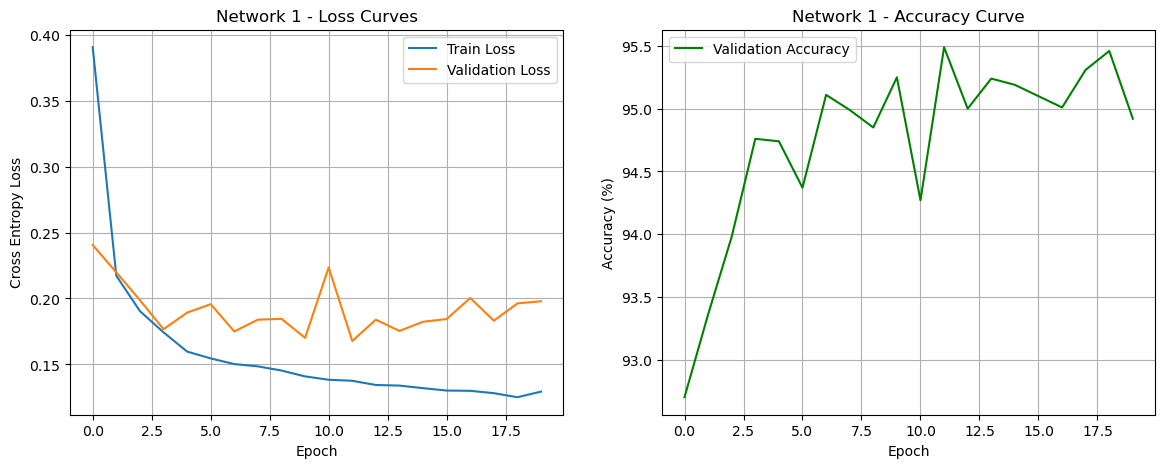

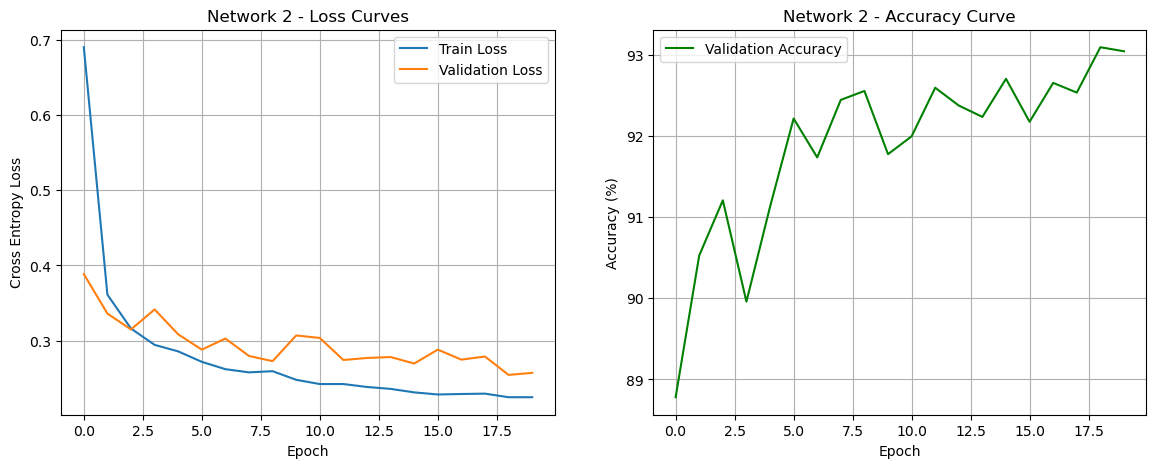

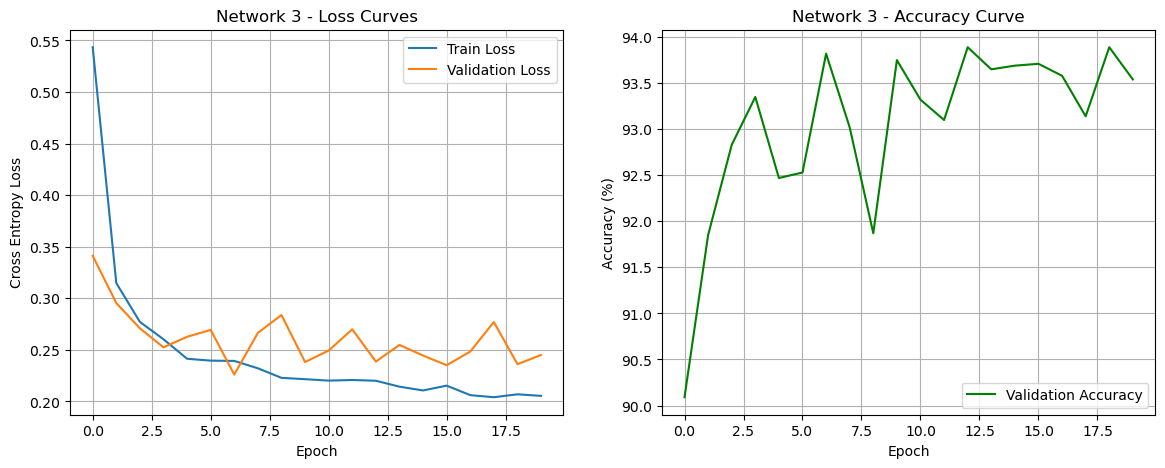

In [10]:
for name, info in results_classification.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(info["train_losses"], label="Train Loss")
    ax1.plot(info["val_losses"], label="Validation Loss")
    ax1.set_title(f"{name} - Loss Curves")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross Entropy Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(info["val_accu"], label="Validation Accuracy", color='green')
    ax2.set_title(f"{name} - Accuracy Curve")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend()
    ax2.grid(True)
    
    plt.show()

Which of the three models had the least amount of error for validation? How long it took to train each model?

In [11]:
#The models were successfully trained and evaluated using accuracy and loss metrics. 
# Deeper networks achieved higher accuracy, although training time increased. The best model was selected based on validation performance.
print("Answer:")
best_model_row = classification_summary.loc[classification_summary['Final Validation Loss'].idxmin()]
best_model_name = best_model_row['Model']
least_err_validation = best_model_row['Final Validation Loss']
print(f"The model with the least validation error was {best_model_name} "
      f"with validation loss = {least_err_validation:.4f}.")

Answer:
The model with the least validation error was Network 1 with validation loss = 0.1979.


In [12]:
print("\nModel Training Times:")
for index, row in classification_summary.iterrows():
    print(f" {row['Model']}: {row['Training Time (sec)']:.2f} seconds")


Model Training Times:
 Network 1: 68.13 seconds
 Network 3: 30.07 seconds
 Network 2: 29.28 seconds
